<a href="https://colab.research.google.com/github/Parvati850/Backend_SEE_Example/blob/main/Programs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Training: Shallow Learning Rate: 0.01
Final Accuracy: 1.0

Training: Shallow Learning Rate: 0.1
Final Accuracy: 1.0

Training: Deep Learning Rate: 0.01
Final Accuracy: 0.99

Training: Deep Learning Rate: 0.1
Final Accuracy: 1.0

-----------------------------
BEST MODEL
-----------------------------
Model: Shallow
Learning Rate: 0.01
Accuracy: 1.0


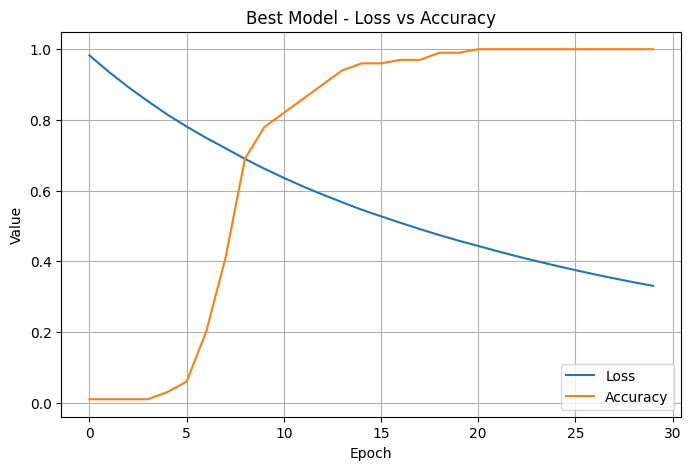

In [ ]:
# Q1. Train a shallow (1 hidden layer) and deep (3 hidden layers) ANN on the first two classes of
# the Iris dataset using two different learning rates (0.01 and 0.1), compare the final training
# accuracy, plot the loss vs accuracy curve for the best model, and state which combination performs
# best.
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler


# 1. Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Use only first two classes: Setosa and Versicolor
X = X[:100]
y = y[:100]


# 2. Scale the input data
scaler = StandardScaler()
X = scaler.fit_transform(X)


# 3. Function to create ANN
def create_model(deep=False):

    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.layers.Input(shape=(4,)))

    # Hidden layers
    if deep:
        # Deep ANN - 3 hidden layers
        model.add(tf.keras.layers.Dense(16, activation='relu'))
        model.add(tf.keras.layers.Dense(16, activation='relu'))
        model.add(tf.keras.layers.Dense(16, activation='relu'))

    else:
        # Shallow ANN - 1 hidden layer
        model.add(tf.keras.layers.Dense(16, activation='relu'))

    # Output layer
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    return model


# 4. Store results
results = {}


# 5. Train shallow and deep models
for model_type in ["Shallow", "Deep"]:

    for lr in [0.01, 0.1]:

        print("\nTraining:", model_type,
              "Learning Rate:", lr)

        # Create model
        model = create_model(deep=(model_type == "Deep"))

        # SGD optimizer
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=lr
        )

        # Compile
        model.compile(
            optimizer=optimizer,
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        # Train
        history = model.fit(
            X,
            y,
            epochs=30,
            verbose=0
        )

        # Final accuracy
        accuracy = history.history['accuracy'][-1]

        print("Final Accuracy:", round(accuracy, 4))

        # Store model and history
        results[(model_type, lr)] = (
            model,
            history,
            accuracy
        )


# 6. Find best combination
best = max(
    results,
    key=lambda x: results[x][2]
)

best_model = results[best][0]
best_history = results[best][1]
best_accuracy = results[best][2]


# 7. Display best result
print("\n-----------------------------")
print("BEST MODEL")
print("-----------------------------")

print("Model:", best[0])
print("Learning Rate:", best[1])
print("Accuracy:", round(best_accuracy, 4))


# 8. Plot loss and accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    best_history.history['loss'],
    label='Loss'
)

plt.plot(
    best_history.history['accuracy'],
    label='Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Value")

plt.title(
    "Best Model - Loss vs Accuracy"
)

plt.legend()
plt.grid()

plt.show()


Training: Shallow Activation: sigmoid
Final Accuracy: 1.0

Training: Shallow Activation: relu
Final Accuracy: 0.95

Training: Deep Activation: sigmoid
Final Accuracy: 0.5

Training: Deep Activation: relu
Final Accuracy: 1.0

FINAL RESULTS
Shallow - sigmoid : 1.0
Shallow - relu : 0.95
Deep - sigmoid : 0.5
Deep - relu : 1.0

BEST MODEL
Model: Shallow
Activation: sigmoid
Accuracy: 1.0


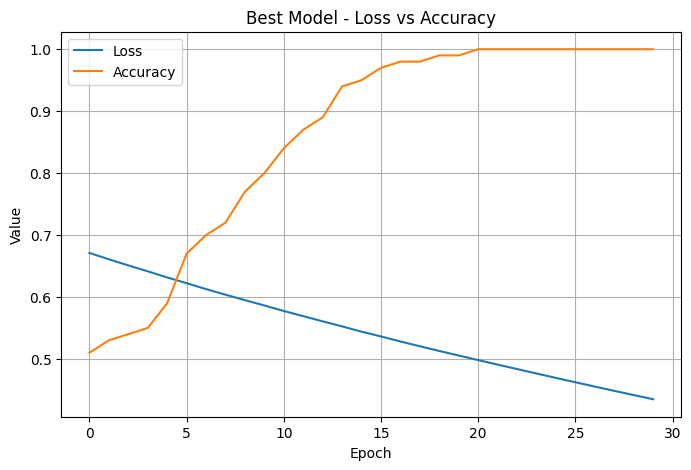

In [ ]:
# Q1. Train a shallow (1 hidden layer) and deep (3 hidden layers) ANN on the first two classes of
# the Iris dataset using Sigmoid and ReLU activations separately, compare the final training
# accuracy, plot the loss vs accuracy curve for the best activation, and explain which activation
# performs better.
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler


# 1. Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target


# 2. Use only first two classes
X = X[:100]
y = y[:100]


# 3. Scale the data
scaler = StandardScaler()
X = scaler.fit_transform(X)


# 4. Function to create ANN
def create_model(deep, activation):

    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.layers.Input(shape=(4,)))

    # Hidden layers
    if deep:
        # Deep ANN - 3 hidden layers
        model.add(tf.keras.layers.Dense(16, activation=activation))
        model.add(tf.keras.layers.Dense(16, activation=activation))
        model.add(tf.keras.layers.Dense(16, activation=activation))

    else:
        # Shallow ANN - 1 hidden layer
        model.add(tf.keras.layers.Dense(16, activation=activation))

    # Output layer
    model.add(
        tf.keras.layers.Dense(1, activation='sigmoid')
    )

    return model


# 5. Store results
results = {}


# 6. Train models
for model_type in ["Shallow", "Deep"]:

    for activation in ["sigmoid", "relu"]:

        print("\nTraining:", model_type,
              "Activation:", activation)

        # Create model
        model = create_model(
            deep=(model_type == "Deep"),
            activation=activation
        )

        # Compile
        model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        # Train
        history = model.fit(
            X,
            y,
            epochs=30,
            verbose=0
        )

        # Final accuracy
        accuracy = history.history['accuracy'][-1]

        print(
            "Final Accuracy:",
            round(accuracy, 4)
        )

        # Store results
        results[(model_type, activation)] = (
            model,
            history,
            accuracy
        )


# 7. Find the best model
best = max(
    results,
    key=lambda x: results[x][2]
)

best_model = results[best][0]
best_history = results[best][1]
best_accuracy = results[best][2]


# 8. Display results
print("\n==============================")
print("FINAL RESULTS")
print("==============================")

for key, value in results.items():

    print(
        key[0],
        "-",
        key[1],
        ":",
        round(value[2], 4)
    )


print("\n==============================")
print("BEST MODEL")
print("==============================")

print("Model:", best[0])
print("Activation:", best[1])
print("Accuracy:", round(best_accuracy, 4))


# 9. Plot loss and accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    best_history.history['loss'],
    label='Loss'
)

plt.plot(
    best_history.history['accuracy'],
    label='Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Value")

plt.title(
    "Best Model - Loss vs Accuracy"
)

plt.legend()
plt.grid()

plt.show()

Final SGD Loss: 0.3595
Final Adam Loss: 0.0078


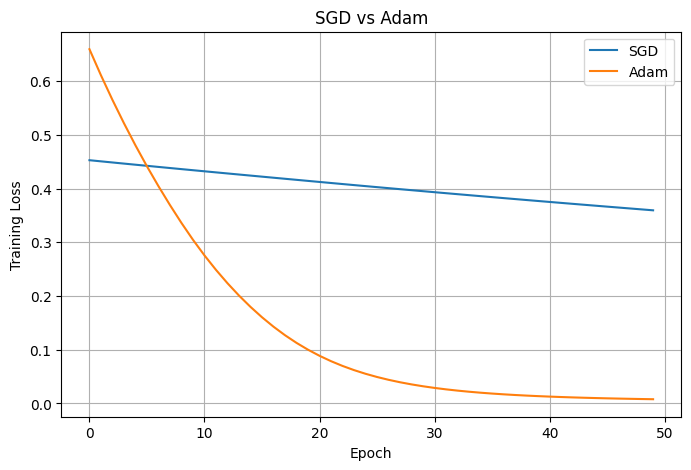

In [ ]:
# Q2. Using TensorFlow/Keras and tf.GradientTape, train a shallow ANN (1 hidden layer) on the
# first two classes of the Iris dataset using two different optimizers (SGD and Adam), plot the
# training loss curves, and explain which optimizer converges faster.
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler


# 1. Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target


# 2. Use first two classes
X = X[:100]
y = y[:100]


# 3. Scale the input data
scaler = StandardScaler()
X = scaler.fit_transform(X)

X = X.astype("float32")
y = y.astype("float32").reshape(-1, 1)


# 4. Create shallow ANN
def create_model():

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(4,)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    return model


# 5. Train using GradientTape
def train_model(optimizer):

    model = create_model()

    loss_function = tf.keras.losses.BinaryCrossentropy()

    losses = []

    # Training
    for epoch in range(50):

        with tf.GradientTape() as tape:

            predictions = model(X, training=True)

            loss = loss_function(y, predictions)

        # Calculate gradients
        gradients = tape.gradient(
            loss,
            model.trainable_variables
        )

        # Update weights
        optimizer.apply_gradients(
            zip(gradients, model.trainable_variables)
        )

        losses.append(float(loss))

    return model, losses


# 6. Train using SGD
sgd = tf.keras.optimizers.SGD(
    learning_rate=0.01
)

sgd_model, sgd_loss = train_model(sgd)


# 7. Train using Adam
adam = tf.keras.optimizers.Adam(
    learning_rate=0.01
)

adam_model, adam_loss = train_model(adam)


# 8. Print final losses
print("Final SGD Loss:",
      round(sgd_loss[-1], 4))

print("Final Adam Loss:",
      round(adam_loss[-1], 4))


# 9. Plot training loss
plt.figure(figsize=(8, 5))

plt.plot(
    sgd_loss,
    label="SGD"
)

plt.plot(
    adam_loss,
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title("SGD vs Adam")

plt.legend()
plt.grid()

plt.show()

Final SGD Loss: 0.4692
Final Adam Loss: 0.0115


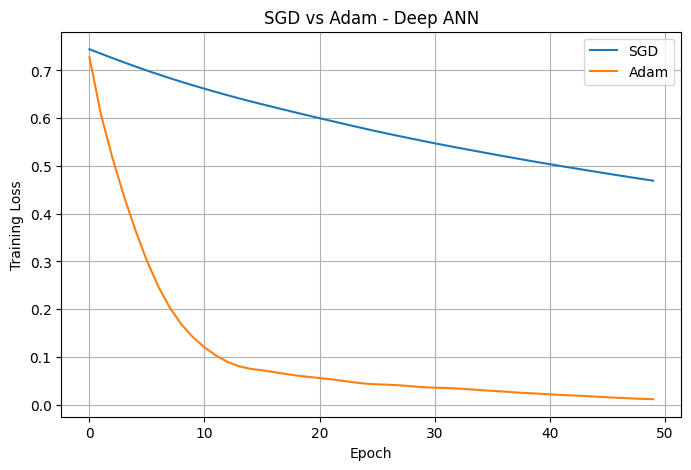

In [ ]:
# Q2. Using TensorFlow/Keras and tf.GradientTape, train a deep ANN (3 hidden layers) on the
# Breast Cancer dataset using the same hyperparameters with SGD and Adam. Plot the training loss
# curves and explain why optimizer choice affects convergence in deeper networks.
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler


# 1. Load Breast Cancer dataset
data = load_breast_cancer()

X = data.data
y = data.target


# 2. Scale the input data
scaler = StandardScaler()
X = scaler.fit_transform(X)

X = X.astype("float32")
y = y.astype("float32").reshape(-1, 1)


# 3. Create Deep ANN
def create_model():

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(30,)),

        # Hidden layer 1
        tf.keras.layers.Dense(
            32,
            activation='relu'
        ),

        # Hidden layer 2
        tf.keras.layers.Dense(
            16,
            activation='relu'
        ),

        # Hidden layer 3
        tf.keras.layers.Dense(
            8,
            activation='relu'
        ),

        # Output layer
        tf.keras.layers.Dense(
            1,
            activation='sigmoid'
        )
    ])

    return model


# 4. Train using GradientTape
def train_model(optimizer):

    model = create_model()

    loss_function = tf.keras.losses.BinaryCrossentropy()

    losses = []

    # Training
    for epoch in range(50):

        with tf.GradientTape() as tape:

            predictions = model(
                X,
                training=True
            )

            loss = loss_function(
                y,
                predictions
            )

        # Calculate gradients
        gradients = tape.gradient(
            loss,
            model.trainable_variables
        )

        # Update weights
        optimizer.apply_gradients(
            zip(
                gradients,
                model.trainable_variables
            )
        )

        losses.append(float(loss))

    return model, losses


# 5. SGD optimizer
sgd = tf.keras.optimizers.SGD(
    learning_rate=0.01
)

sgd_model, sgd_loss = train_model(sgd)


# 6. Adam optimizer
adam = tf.keras.optimizers.Adam(
    learning_rate=0.01
)

adam_model, adam_loss = train_model(adam)


# 7. Display final losses
print("Final SGD Loss:",
      round(sgd_loss[-1], 4))

print("Final Adam Loss:",
      round(adam_loss[-1], 4))


# 8. Plot training loss
plt.figure(figsize=(8, 5))

plt.plot(
    sgd_loss,
    label="SGD"
)

plt.plot(
    adam_loss,
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "SGD vs Adam - Deep ANN"
)

plt.legend()
plt.grid()

plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Training WITHOUT Dropout


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9078 - loss: 0.3242 - val_accuracy: 0.9489 - val_loss: 0.1696
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9601 - loss: 0.1344 - val_accuracy: 0.9642 - val_loss: 0.1198
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9726 - loss: 0.0927 - val_accuracy: 0.9711 - val_loss: 0.0930
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9785 - loss: 0.0707 - val_accuracy: 0.9707 - val_loss: 0.0948
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9824 - loss: 0.0568 - val_accuracy: 0.9737 - val_loss: 0.0812
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9861 - loss: 0.0464 - val_accuracy: 0.9754 - val_loss: 0.0777
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9886 - loss: 0.0373 - val_accuracy: 0.9764 - val_loss: 0.0784
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9905 - loss: 0.0307 - val_accuracy

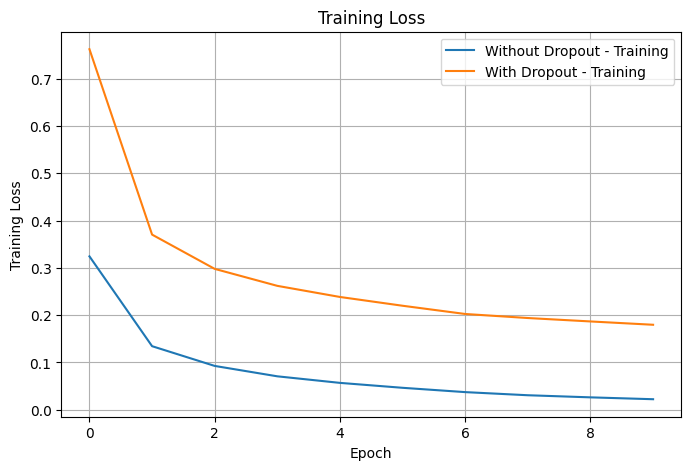

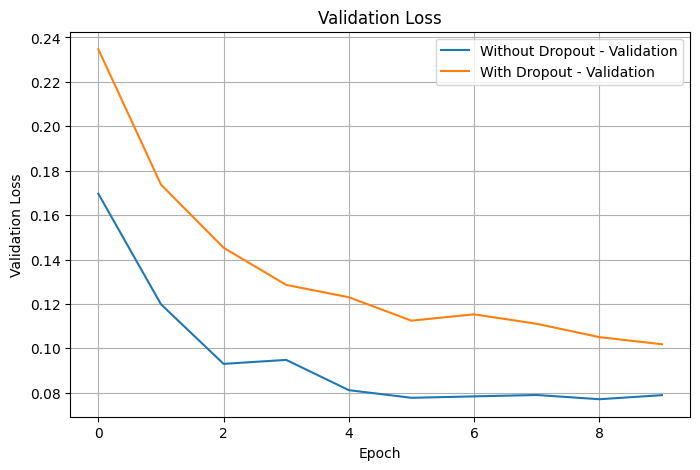


Final Results
Without Dropout - Training Accuracy: 0.9935
Without Dropout - Validation Accuracy: 0.9778
With Dropout - Training Accuracy: 0.9486
With Dropout - Validation Accuracy: 0.9715


In [ ]:
# Q3. Using TensorFlow/Keras, train a deep ANN (2 hidden layers) on the MNIST dataset once
# without any regularization and once with dropout. Plot the training and validation loss curves and
# explain how dropout reduces overfitting.
import tensorflow as tf
import matplotlib.pyplot as plt


# 1. Load MNIST dataset
(X_train, y_train), (X_test, y_test) = \
    tf.keras.datasets.mnist.load_data()


# 2. Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0


# 3. Function to create model
def create_model(use_dropout=False):

    model = tf.keras.Sequential()

    # Input layer
    model.add(
        tf.keras.layers.Flatten(
            input_shape=(28, 28)
        )
    )

    # Hidden layer 1
    model.add(
        tf.keras.layers.Dense(
            128,
            activation='relu'
        )
    )

    # Dropout
    if use_dropout:
        model.add(
            tf.keras.layers.Dropout(0.5)
        )

    # Hidden layer 2
    model.add(
        tf.keras.layers.Dense(
            64,
            activation='relu'
        )
    )

    # Dropout
    if use_dropout:
        model.add(
            tf.keras.layers.Dropout(0.5)
        )

    # Output layer
    model.add(
        tf.keras.layers.Dense(
            10,
            activation='softmax'
        )
    )

    return model


# 4. Train model
def train_model(use_dropout):

    model = create_model(use_dropout)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=128,
        verbose=1
    )

    return model, history


# 5. Train without Dropout
print("\nTraining WITHOUT Dropout")

model_without, history_without = \
    train_model(False)


# 6. Train with Dropout
print("\nTraining WITH Dropout")

model_with, history_with = \
    train_model(True)


# 7. Plot training loss
plt.figure(figsize=(8, 5))

plt.plot(
    history_without.history['loss'],
    label='Without Dropout - Training'
)

plt.plot(
    history_with.history['loss'],
    label='With Dropout - Training'
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title("Training Loss")

plt.legend()
plt.grid()

plt.show()


# 8. Plot validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    history_without.history['val_loss'],
    label='Without Dropout - Validation'
)

plt.plot(
    history_with.history['val_loss'],
    label='With Dropout - Validation'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title("Validation Loss")

plt.legend()
plt.grid()

plt.show()


# 9. Final results
print("\nFinal Results")

print(
    "Without Dropout - Training Accuracy:",
    round(history_without.history['accuracy'][-1], 4)
)

print(
    "Without Dropout - Validation Accuracy:",
    round(history_without.history['val_accuracy'][-1], 4)
)

print(
    "With Dropout - Training Accuracy:",
    round(history_with.history['accuracy'][-1], 4)
)

print(
    "With Dropout - Validation Accuracy:",
    round(history_with.history['val_accuracy'][-1], 4)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9063 - loss: 0.3328 - val_accuracy: 0.9513 - val_loss: 0.1667
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9610 - loss: 0.1341 - val_accuracy: 0.9643 - val_loss: 0.1163
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9728 - loss: 0.0925 - val_accuracy: 0.9698 - val_loss: 0.0946
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9793 - loss: 0.0703 - val_accuracy: 0.9732 - val_loss: 0.0872
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9837 - loss: 0.0540 - val_accuracy: 0.9743 - val_loss: 0.0805
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9869 - loss: 0.0434 - val_accuracy: 0.9763 - val_loss: 0.0769
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9895 - loss: 0.0350 - val_accuracy: 0.9778 - val_loss: 0.0745
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9914 - loss: 0.0290 - val_accuracy: 0.

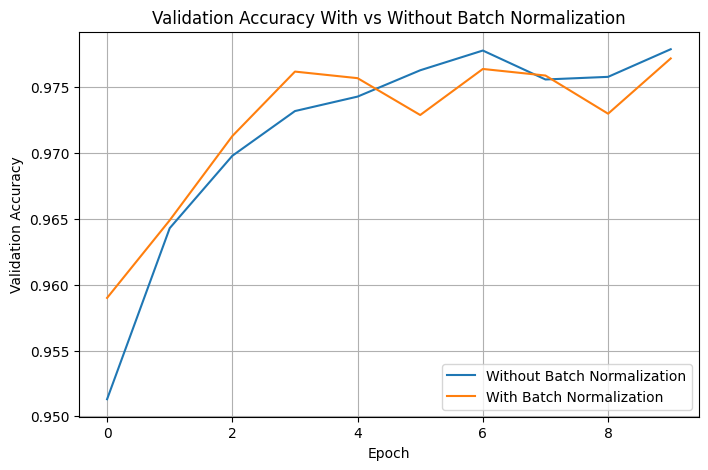

Final Validation Accuracy without BN: 0.9779
Final Validation Accuracy with BN: 0.9772


In [ ]:
# Q3. Train a deep ANN (2 hidden layers) on the MNIST dataset with and without batch
# normalization. Plot validation accuracy across epochs and justify how batch normalization
# improves training stability and convergence.
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Load MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


# 3. Create ANN model
def create_model(use_bn=False):

    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))

    # Hidden layer 1
    model.add(tf.keras.layers.Dense(128, activation="relu"))

    # Batch Normalization
    if use_bn:
        model.add(tf.keras.layers.BatchNormalization())

    # Hidden layer 2
    model.add(tf.keras.layers.Dense(64, activation="relu"))

    # Batch Normalization
    if use_bn:
        model.add(tf.keras.layers.BatchNormalization())

    # Output layer
    model.add(tf.keras.layers.Dense(10, activation="softmax"))

    return model


# 4. Train model
def train_model(use_bn):

    model = create_model(use_bn)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=128,
        verbose=1
    )

    return model, history


# 5. Train without Batch Normalization
model_without_bn, history_without_bn = train_model(False)

# 6. Train with Batch Normalization
model_with_bn, history_with_bn = train_model(True)


# 7. Plot validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history_without_bn.history["val_accuracy"],
    label="Without Batch Normalization"
)

plt.plot(
    history_with_bn.history["val_accuracy"],
    label="With Batch Normalization"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy With vs Without Batch Normalization")

plt.legend()
plt.grid()
plt.show()


# 8. Display final validation accuracy
print(
    "Final Validation Accuracy without BN:",
    round(history_without_bn.history["val_accuracy"][-1], 4)
)

print(
    "Final Validation Accuracy with BN:",
    round(history_with_bn.history["val_accuracy"][-1], 4)
)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training with Constant Learning Rate...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8124 - loss: 0.5421 - val_accuracy: 0.8506 - val_loss: 0.4251
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8631 - loss: 0.3863 - val_accuracy: 0.8626 - val_loss: 0.3895
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8738 - loss: 0.3466 - val_accuracy: 0.8705 - val_loss: 0.3640
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8839 - loss: 0.3191 - val_accuracy: 0.8654 - val_loss: 0.3720
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8895 - loss: 0.3011 - val_accuracy: 0.8709 - val_loss: 0.3603
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8933 - loss: 0.2899 - val_accuracy: 0.8740 - val_loss: 0.3462
Epoc

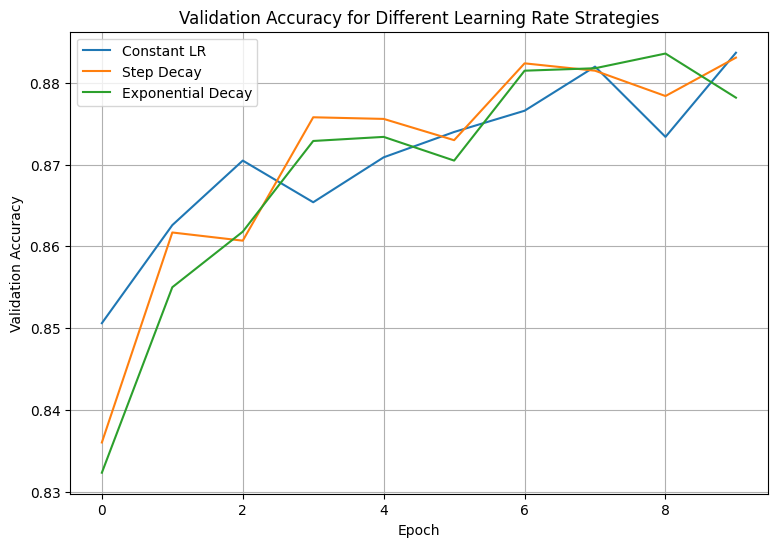


Final Validation Accuracy:
Constant LR: 0.8837
Step Decay: 0.8831
Exponential Decay: 0.8782


In [ ]:
# Q4. Using TensorFlow/Keras, train a deep ANN (2 hidden layers) on the Fashion-MNIST dataset
# using the Adam optimizer with three different learning rate decay strategies (constant LR, StepDecay, and Exponential Decay). Plot validation accuracy and explain which strategy gives better
# generalization performance.
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Load Fashion-MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# 2. Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


# 3. Create the ANN
def create_model():

    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),

        # Hidden layer 1
        tf.keras.layers.Dense(128, activation="relu"),

        # Hidden layer 2
        tf.keras.layers.Dense(64, activation="relu"),

        # Output layer
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    return model


# 4. Train with constant learning rate
def train_constant():

    model = create_model()

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=128,
        verbose=1
    )

    return history


# 5. Train with Step Decay
def train_step_decay():

    model = create_model()

    initial_lr = 0.001

    def step_decay(epoch):
        drop = 0.5
        epochs_drop = 3
        return initial_lr * (drop ** (epoch // epochs_drop))

    lr_scheduler = tf.keras.callbacks.LearningRateScheduler(
        step_decay
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=128,
        callbacks=[lr_scheduler],
        verbose=1
    )

    return history


# 6. Train with Exponential Decay
def train_exponential_decay():

    model = create_model()

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001,
        decay_steps=1000,
        decay_rate=0.9
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=lr_schedule
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=128,
        verbose=1
    )

    return history


# 7. Train all three models

print("Training with Constant Learning Rate...")
history_constant = train_constant()

print("\nTraining with Step Decay...")
history_step = train_step_decay()

print("\nTraining with Exponential Decay...")
history_exp = train_exponential_decay()


# 8. Plot validation accuracy

plt.figure(figsize=(9, 6))

plt.plot(
    history_constant.history["val_accuracy"],
    label="Constant LR"
)

plt.plot(
    history_step.history["val_accuracy"],
    label="Step Decay"
)

plt.plot(
    history_exp.history["val_accuracy"],
    label="Exponential Decay"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Different Learning Rate Strategies")

plt.legend()
plt.grid()
plt.show()


# 9. Print final validation accuracy

print("\nFinal Validation Accuracy:")

print(
    "Constant LR:",
    round(history_constant.history["val_accuracy"][-1], 4)
)

print(
    "Step Decay:",
    round(history_step.history["val_accuracy"][-1], 4)
)

print(
    "Exponential Decay:",
    round(history_exp.history["val_accuracy"][-1], 4)
)

Training with SGD...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6478 - loss: 1.1382 - val_accuracy: 0.7323 - val_loss: 0.7804
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7708 - loss: 0.6818 - val_accuracy: 0.7821 - val_loss: 0.6386
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8011 - loss: 0.5866 - val_accuracy: 0.8000 - val_loss: 0.5803
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8150 - loss: 0.5388 - val_accuracy: 0.8128 - val_loss: 0.5436
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8243 - loss: 0.5081 - val_accuracy: 0.8139 - val_loss: 0.5279
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8323 - loss: 0.4863 - val_accuracy: 0.8231 - val_loss: 0.5041
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8359 - loss: 0.4710 - val_accuracy: 0.8309 - val_loss: 0.4905
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8402 - loss: 0.45

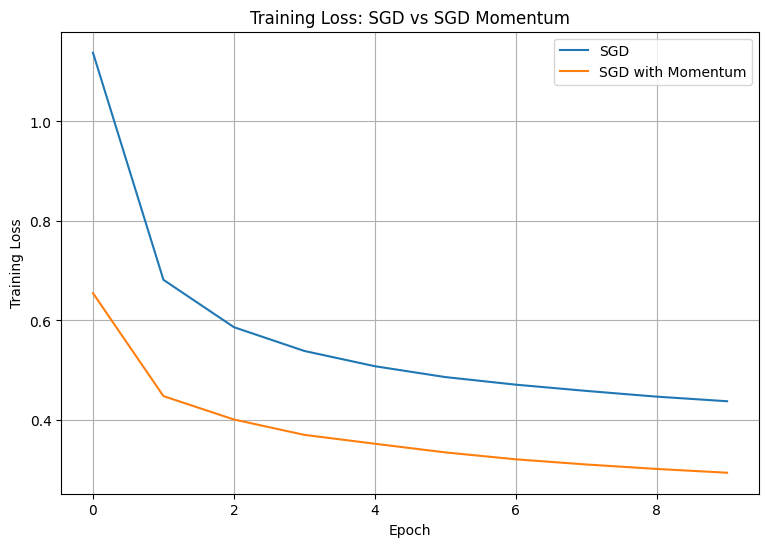


Final Training Loss:
SGD: 0.4377
SGD with Momentum: 0.294


In [ ]:
# Q4. Train the same ANN architecture on the Fashion-MNIST dataset using SGD and SGD with
# Momentum. Plot training loss curves and justify how momentum affects convergence behavior,
# especially in noisy gradients.
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Load Fashion-MNIST
(X_train, y_train), (X_test, y_test) = \
    tf.keras.datasets.fashion_mnist.load_data()

# 2. Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


# 3. Create the ANN
def create_model():

    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),

        # Hidden layer 1
        tf.keras.layers.Dense(128, activation="relu"),

        # Hidden layer 2
        tf.keras.layers.Dense(64, activation="relu"),

        # Output layer
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    return model


# 4. Train using selected optimizer
def train_model(optimizer):

    model = create_model()

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=128,
        verbose=1
    )

    return history


# 5. SGD
print("Training with SGD...")

sgd_optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01
)

history_sgd = train_model(sgd_optimizer)


# 6. SGD with Momentum
print("\nTraining with SGD Momentum...")

momentum_optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9
)

history_momentum = train_model(momentum_optimizer)


# 7. Plot training loss
plt.figure(figsize=(9, 6))

plt.plot(
    history_sgd.history["loss"],
    label="SGD"
)

plt.plot(
    history_momentum.history["loss"],
    label="SGD with Momentum"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss: SGD vs SGD Momentum")

plt.legend()
plt.grid()
plt.show()


# 8. Print final training loss
print("\nFinal Training Loss:")

print(
    "SGD:",
    round(history_sgd.history["loss"][-1], 4)
)

print(
    "SGD with Momentum:",
    round(history_momentum.history["loss"][-1], 4)
)

Dataset shape: (1797, 8, 8, 1)
Training with VALID padding...
Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6033 - loss: 1.9935 - val_accuracy: 0.7750 - val_loss: 1.6033
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8372 - loss: 1.1402 - val_accuracy: 0.8917 - val_loss: 0.7122
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8991 - loss: 0.5493 - val_accuracy: 0.9111 - val_loss: 0.4170
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9283 - loss: 0.3543 - val_accuracy: 0.9306 - val_loss: 0.2882
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9436 - loss: 0.2656 - val_accuracy: 0.9528 - val_loss: 0.2280
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9541 - loss: 0.2056 - val_accuracy: 0.9500 - val_loss: 0.1905
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9631 - loss: 0.1725 - val_accuracy: 0.9583 - val_loss: 0.1588
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9722 - loss: 0.1431 - val_accuracy: 0.9528 - val_loss: 0.1657
Epo

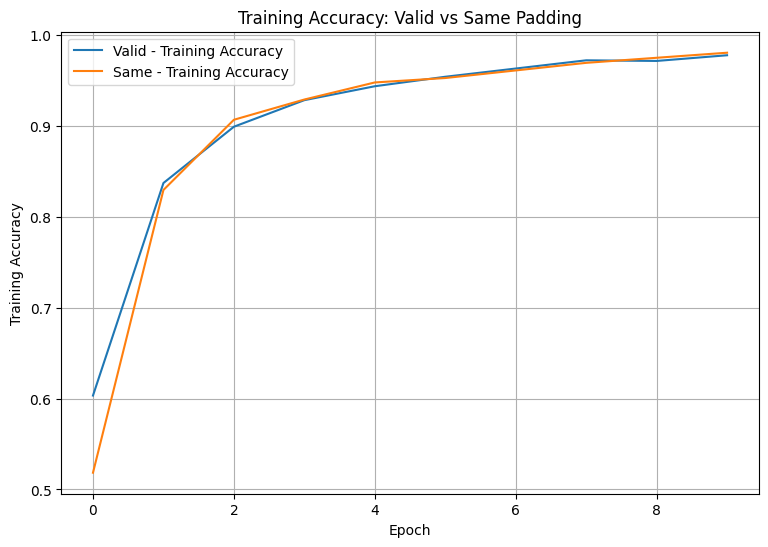

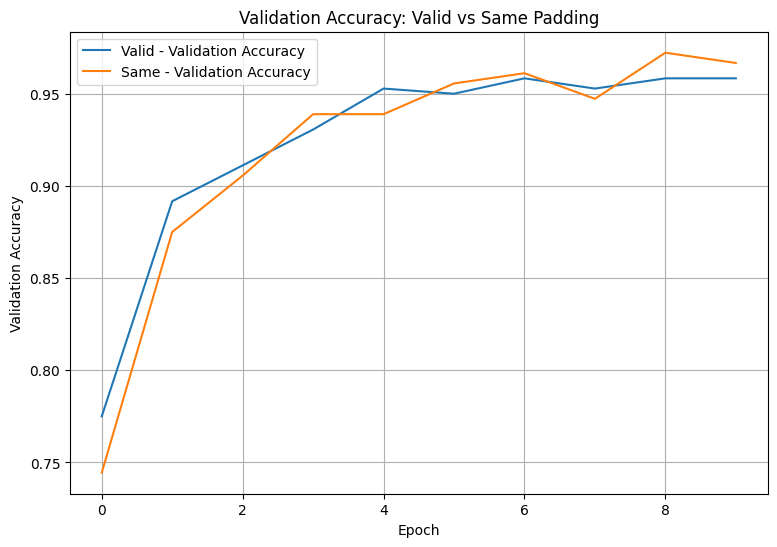


Final Results
VALID - Training Accuracy: 0.9777
VALID - Validation Accuracy: 0.9583
SAME - Training Accuracy: 0.9805
SAME - Validation Accuracy: 0.9667


In [ ]:
# Q5. Using TensorFlow/Keras, train a simple CNN on the scikit-learn Digits dataset using the same
# architecture twice — once with padding="valid" and once with padding="same" in the convolution
# layer. Plot the training and validation accuracy curves and explain how padding affects feature
# extraction and classification performance. (Train a CNN on the Digits dataset twice with the same
# architecture — once with padding="valid" and once with padding="same" — and plot training &
# validation accuracy.)
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


# 1. Load Digits dataset
digits = load_digits()

X = digits.images
y = digits.target


# 2. Normalize pixel values
X = X.astype("float32") / 16.0


# 3. Add channel dimension
X = X[..., np.newaxis]

print("Dataset shape:", X.shape)


# 4. Split into training and validation data
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 5. Create CNN
def create_model(padding):

    model = tf.keras.Sequential([

        # Convolution layer
        tf.keras.layers.Conv2D(
            32,
            kernel_size=(3, 3),
            activation="relu",
            padding=padding,
            input_shape=(8, 8, 1)
        ),

        # Pooling
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # Flatten
        tf.keras.layers.Flatten(),

        # Fully connected layer
        tf.keras.layers.Dense(64, activation="relu"),

        # Output layer
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    return model


# 6. Train model
def train_model(padding):

    model = create_model(padding)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=32,
        verbose=1
    )

    return history


# 7. Train with VALID padding
print("Training with VALID padding...")
history_valid = train_model("valid")


# 8. Train with SAME padding
print("\nTraining with SAME padding...")
history_same = train_model("same")


# 9. Plot training accuracy
plt.figure(figsize=(9, 6))

plt.plot(
    history_valid.history["accuracy"],
    label="Valid - Training Accuracy"
)

plt.plot(
    history_same.history["accuracy"],
    label="Same - Training Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy: Valid vs Same Padding")
plt.legend()
plt.grid()
plt.show()


# 10. Plot validation accuracy
plt.figure(figsize=(9, 6))

plt.plot(
    history_valid.history["val_accuracy"],
    label="Valid - Validation Accuracy"
)

plt.plot(
    history_same.history["val_accuracy"],
    label="Same - Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: Valid vs Same Padding")
plt.legend()
plt.grid()
plt.show()


# 11. Print final accuracies
print("\nFinal Results")

print(
    "VALID - Training Accuracy:",
    round(history_valid.history["accuracy"][-1], 4)
)

print(
    "VALID - Validation Accuracy:",
    round(history_valid.history["val_accuracy"][-1], 4)
)

print(
    "SAME - Training Accuracy:",
    round(history_same.history["accuracy"][-1], 4)
)

print(
    "SAME - Validation Accuracy:",
    round(history_same.history["val_accuracy"][-1], 4)
)

Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3925 - loss: 2.0911 - val_accuracy: 0.6000 - val_loss: 1.7847
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7829 - loss: 1.3401 - val_accuracy: 0.7972 - val_loss: 0.9350
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8671 - loss: 0.6754 - val_accuracy: 0.8722 - val_loss: 0.5010
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9074 - loss: 0.4016 - val_accuracy: 0.9083 - val_loss: 0.3573
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9228 - loss: 0.2974 - val_accuracy: 0.9278 - val_loss: 0.2791
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9367 - loss: 0.2362 - val_accuracy: 0.9333 - val_loss: 0.2143
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9541 - loss: 0.1878 - val_accuracy: 0.9417 - val_loss: 0.1987
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9569 - loss: 0.1681 - val_accuracy: 0.9500 - val_loss: 0.1719
Ep

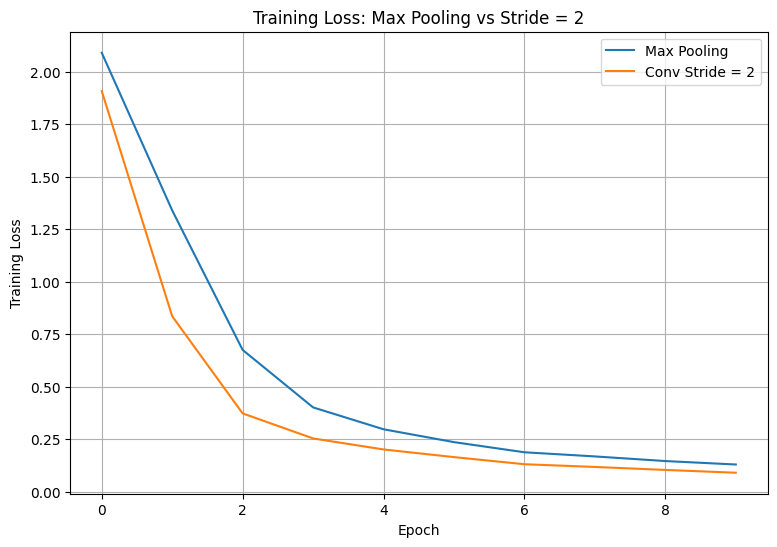


Final Training Loss
Max Pooling: 0.1296
Conv Stride = 2: 0.0904


In [ ]:
# Q5. Train two CNN models on the scikit-learn Digits dataset: one using a max-pooling layer and
# the other replacing pooling with a convolution layer with stride=2 for downsampling. Plot the
# training loss curves and justify which approach leads to better convergence behavior. (Train two
# CNNs on Digits — one with max-pooling, one with stride=2 conv for downsampling — and plot
# training loss curves.)
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


# 1. Load Digits dataset
digits = load_digits()

X = digits.images
y = digits.target


# 2. Normalize pixel values
X = X.astype("float32") / 16.0


# 3. Add channel dimension
X = X[..., np.newaxis]


# 4. Split dataset
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 5. CNN with Max Pooling
def create_maxpool_model():

    model = tf.keras.Sequential([

        tf.keras.layers.Conv2D(
            32,
            kernel_size=(3, 3),
            activation="relu",
            padding="same",
            input_shape=(8, 8, 1)
        ),

        # Max Pooling for downsampling
        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2)
        ),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            64,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            10,
            activation="softmax"
        )
    ])

    return model


# 6. CNN with Stride = 2
def create_stride_model():

    model = tf.keras.Sequential([

        # Stride = 2 performs downsampling
        tf.keras.layers.Conv2D(
            32,
            kernel_size=(3, 3),
            strides=2,
            activation="relu",
            padding="same",
            input_shape=(8, 8, 1)
        ),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            64,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            10,
            activation="softmax"
        )
    ])

    return model


# 7. Train Max Pooling model
maxpool_model = create_maxpool_model()

maxpool_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_maxpool = maxpool_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)


# 8. Train Stride = 2 model
stride_model = create_stride_model()

stride_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_stride = stride_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)


# 9. Plot training loss
plt.figure(figsize=(9, 6))

plt.plot(
    history_maxpool.history["loss"],
    label="Max Pooling"
)

plt.plot(
    history_stride.history["loss"],
    label="Conv Stride = 2"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss: Max Pooling vs Stride = 2")

plt.legend()
plt.grid()
plt.show()


# 10. Print final training loss
print("\nFinal Training Loss")

print(
    "Max Pooling:",
    round(history_maxpool.history["loss"][-1], 4)
)

print(
    "Conv Stride = 2:",
    round(history_stride.history["loss"][-1], 4)
)

Image shape: (1797, 8, 8, 1)
Bounding box shape: (1797, 4)
Training 1-Convolution CNN...
Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - iou_metric: 0.6100 - loss: 0.0222 - val_iou_metric: 0.8809 - val_loss: 0.0013
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - iou_metric: 0.8700 - loss: 0.0014 - val_iou_metric: 0.8895 - val_loss: 0.0010
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - iou_metric: 0.8819 - loss: 0.0012 - val_iou_metric: 0.8980 - val_loss: 8.8256e-04
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - iou_metric: 0.8886 - loss: 0.0010 - val_iou_metric: 0.9044 - val_loss: 7.7806e-04
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - iou_metric: 0.8938 - loss: 9.1086e-04 - val_iou_metric: 0.9049 - val_loss: 6.9736e-04
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - iou_metric: 0.8976 - loss: 8.1478e-04 - val_iou_metric: 0.9092 - val_loss: 6.2032e-04
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - iou_metric: 0.8998 - loss: 7.4676e-04 - val_iou_metric

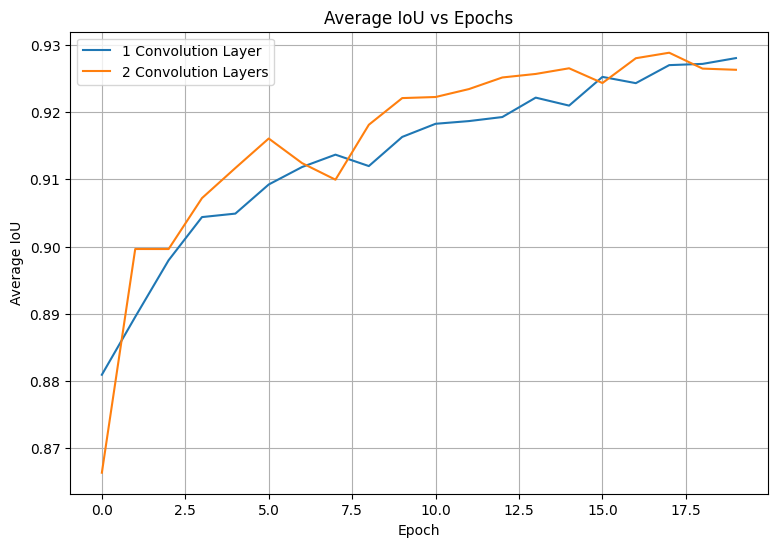


Final Average IoU:
1-Convolution CNN: 0.928
2-Convolution CNN: 0.9263


In [ ]:
# Q6. Train two CNN models (one with 1 convolution layer and one with 2 convolution layers) to
# predict bounding boxes on the scikit-learn Digits dataset. Compare them using average IoU, plot
# IoU vs epochs, and explain which model localizes digits better.
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


# --------------------------------------------------
# 1. Load Digits dataset
# --------------------------------------------------

digits = load_digits()

X = digits.images
y = digits.target


# Normalize images
X = X.astype("float32") / 16.0

# Add channel dimension
X = X[..., np.newaxis]


# --------------------------------------------------
# 2. Create bounding-box labels
# --------------------------------------------------
# Bounding box format:
# [x_min, y_min, x_max, y_max]

def create_bounding_box(image):

    # Remove channel dimension
    img = image[:, :, 0]

    # Find pixels belonging to the digit
    rows, cols = np.where(img > 0)

    x_min = cols.min()
    y_min = rows.min()
    x_max = cols.max()
    y_max = rows.max()

    # Normalize coordinates to 0-1
    x_min = x_min / 8.0
    y_min = y_min / 8.0
    x_max = x_max / 8.0
    y_max = y_max / 8.0

    return [x_min, y_min, x_max, y_max]


# Create bounding boxes
boxes = np.array([
    create_bounding_box(image)
    for image in X
], dtype="float32")


print("Image shape:", X.shape)
print("Bounding box shape:", boxes.shape)


# --------------------------------------------------
# 3. Train-validation split
# --------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X,
    boxes,
    test_size=0.2,
    random_state=42
)


# --------------------------------------------------
# 4. IoU calculation
# --------------------------------------------------

def calculate_iou(y_true, y_pred):

    # True box
    true_x1 = y_true[:, 0]
    true_y1 = y_true[:, 1]
    true_x2 = y_true[:, 2]
    true_y2 = y_true[:, 3]

    # Predicted box
    pred_x1 = y_pred[:, 0]
    pred_y1 = y_pred[:, 1]
    pred_x2 = y_pred[:, 2]
    pred_y2 = y_pred[:, 3]

    # Intersection
    inter_x1 = tf.maximum(true_x1, pred_x1)
    inter_y1 = tf.maximum(true_y1, pred_y1)
    inter_x2 = tf.minimum(true_x2, pred_x2)
    inter_y2 = tf.minimum(true_y2, pred_y2)

    inter_width = tf.maximum(0.0, inter_x2 - inter_x1)
    inter_height = tf.maximum(0.0, inter_y2 - inter_y1)

    intersection = inter_width * inter_height

    # True box area
    true_area = (
        (true_x2 - true_x1) *
        (true_y2 - true_y1)
    )

    # Predicted box area
    pred_area = (
        (pred_x2 - pred_x1) *
        (pred_y2 - pred_y1)
    )

    # Union
    union = true_area + pred_area - intersection

    # IoU
    iou = intersection / (union + 1e-7)

    return iou


# --------------------------------------------------
# 5. Custom IoU metric
# --------------------------------------------------

def iou_metric(y_true, y_pred):

    # Keep predictions between 0 and 1
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)

    return tf.reduce_mean(
        calculate_iou(y_true, y_pred)
    )


# --------------------------------------------------
# 6. Create 1-convolution CNN
# --------------------------------------------------

def create_one_conv_model():

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(8, 8, 1)),

        tf.keras.layers.Conv2D(
            32,
            (3, 3),
            activation="relu",
            padding="same"
        ),

        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            64,
            activation="relu"
        ),

        # 4 outputs:
        # x_min, y_min, x_max, y_max
        tf.keras.layers.Dense(
            4,
            activation="sigmoid"
        )
    ])

    return model


# --------------------------------------------------
# 7. Create 2-convolution CNN
# --------------------------------------------------

def create_two_conv_model():

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(8, 8, 1)),

        tf.keras.layers.Conv2D(
            32,
            (3, 3),
            activation="relu",
            padding="same"
        ),

        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(
            64,
            (3, 3),
            activation="relu",
            padding="same"
        ),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            64,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            4,
            activation="sigmoid"
        )
    ])

    return model


# --------------------------------------------------
# 8. Train function
# --------------------------------------------------

def train_model(model):

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=[iou_metric]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=32,
        verbose=1
    )

    return history


# --------------------------------------------------
# 9. Train 1-convolution model
# --------------------------------------------------

print("Training 1-Convolution CNN...")

model_1conv = create_one_conv_model()

history_1conv = train_model(model_1conv)


# --------------------------------------------------
# 10. Train 2-convolution model
# --------------------------------------------------

print("\nTraining 2-Convolution CNN...")

model_2conv = create_two_conv_model()

history_2conv = train_model(model_2conv)


# --------------------------------------------------
# 11. Plot IoU vs Epochs
# --------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    history_1conv.history["val_iou_metric"],
    label="1 Convolution Layer"
)

plt.plot(
    history_2conv.history["val_iou_metric"],
    label="2 Convolution Layers"
)

plt.xlabel("Epoch")
plt.ylabel("Average IoU")
plt.title("Average IoU vs Epochs")

plt.legend()
plt.grid()

plt.show()


# --------------------------------------------------
# 12. Print final IoU
# --------------------------------------------------

final_iou_1 = history_1conv.history["val_iou_metric"][-1]

final_iou_2 = history_2conv.history["val_iou_metric"][-1]

print("\nFinal Average IoU:")

print(
    "1-Convolution CNN:",
    round(final_iou_1, 4)
)

print(
    "2-Convolution CNN:",
    round(final_iou_2, 4)
)

Dataset shape: (20000, 28, 28, 1)
Bounding box shape: (20000, 4)

Training 1-Convolution CNN...
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - iou_metric: 0.8570 - loss: 0.0027 - val_iou_metric: 0.9183 - val_loss: 3.9597e-04
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - iou_metric: 0.9282 - loss: 3.1113e-04 - val_iou_metric: 0.9388 - val_loss: 2.3050e-04
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - iou_metric: 0.9402 - loss: 2.1796e-04 - val_iou_metric: 0.9437 - val_loss: 1.9002e-04
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - iou_metric: 0.9448 - loss: 1.8303e-04 - val_iou_metric: 0.9411 - val_loss: 1.9819e-04
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - iou_metric: 0.9473 - loss: 1.6597e-04 - val_iou_metric: 0.9490 - val_loss: 1.5856e-04
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - iou_metric: 0.9494 - loss: 1.5303e-04 - val_iou_metric: 0.9499 - val_loss: 1.5285e-04
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - iou_me

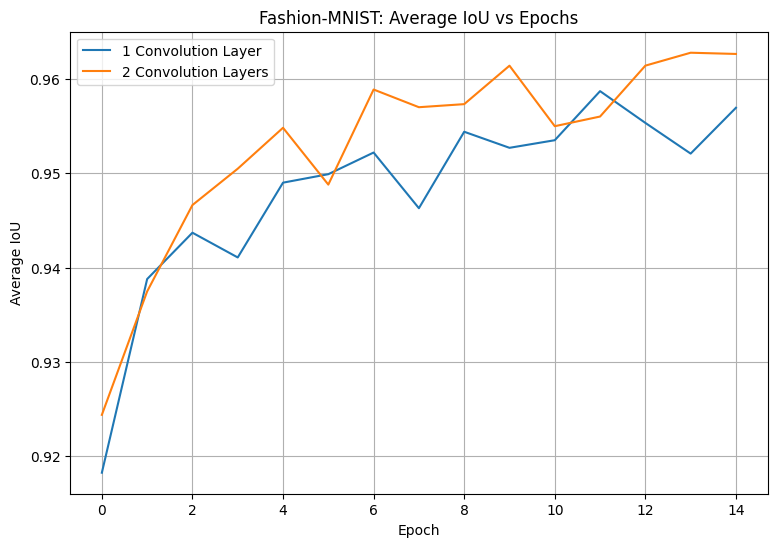


Final Average IoU
1-Convolution CNN: 0.957
2-Convolution CNN: 0.9627


In [ ]:
# Q6. Train two CNN models (1-conv and 2-conv) to predict bounding boxes on the Fashion-MNIST
# dataset. Compare their average IoU, plot IoU vs epochs, and explain which model provides better
# object localization.
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split


# --------------------------------------------------
# 1. Load Fashion-MNIST
# --------------------------------------------------

(X, y), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# Use a smaller subset for faster lab execution
X = X[:20000]
y = y[:20000]

# Normalize pixel values
X = X.astype("float32") / 255.0

# Add channel dimension
X = X[..., np.newaxis]

print("Dataset shape:", X.shape)


# --------------------------------------------------
# 2. Create bounding boxes
# --------------------------------------------------
# Format:
# [x_min, y_min, x_max, y_max]

def create_bounding_box(image):

    # Remove channel dimension
    img = image[:, :, 0]

    # Find non-zero pixels
    rows, cols = np.where(img > 0.05)

    x_min = cols.min()
    y_min = rows.min()
    x_max = cols.max()
    y_max = rows.max()

    # Normalize coordinates to 0-1
    return [
        x_min / 28.0,
        y_min / 28.0,
        x_max / 28.0,
        y_max / 28.0
    ]


# Create bounding boxes
boxes = np.array([
    create_bounding_box(image)
    for image in X
], dtype="float32")

print("Bounding box shape:", boxes.shape)


# --------------------------------------------------
# 3. Train-validation split
# --------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X,
    boxes,
    test_size=0.2,
    random_state=42
)


# --------------------------------------------------
# 4. IoU calculation
# --------------------------------------------------

def calculate_iou(y_true, y_pred):

    # True box
    true_x1 = y_true[:, 0]
    true_y1 = y_true[:, 1]
    true_x2 = y_true[:, 2]
    true_y2 = y_true[:, 3]

    # Predicted box
    pred_x1 = y_pred[:, 0]
    pred_y1 = y_pred[:, 1]
    pred_x2 = y_pred[:, 2]
    pred_y2 = y_pred[:, 3]

    # Intersection
    inter_x1 = tf.maximum(true_x1, pred_x1)
    inter_y1 = tf.maximum(true_y1, pred_y1)
    inter_x2 = tf.minimum(true_x2, pred_x2)
    inter_y2 = tf.minimum(true_y2, pred_y2)

    inter_width = tf.maximum(
        0.0,
        inter_x2 - inter_x1
    )

    inter_height = tf.maximum(
        0.0,
        inter_y2 - inter_y1
    )

    intersection = inter_width * inter_height

    # Areas
    true_area = (
        (true_x2 - true_x1) *
        (true_y2 - true_y1)
    )

    pred_area = (
        (pred_x2 - pred_x1) *
        (pred_y2 - pred_y1)
    )

    # Union
    union = true_area + pred_area - intersection

    # IoU
    iou = intersection / (union + 1e-7)

    return iou


# --------------------------------------------------
# 5. IoU metric
# --------------------------------------------------

def iou_metric(y_true, y_pred):

    y_pred = tf.clip_by_value(
        y_pred,
        0.0,
        1.0
    )

    return tf.reduce_mean(
        calculate_iou(y_true, y_pred)
    )


# --------------------------------------------------
# 6. One-Convolution CNN
# --------------------------------------------------

def create_one_conv_model():

    model = tf.keras.Sequential([

        tf.keras.layers.Input(
            shape=(28, 28, 1)
        ),

        tf.keras.layers.Conv2D(
            32,
            (3, 3),
            activation="relu",
            padding="same"
        ),

        tf.keras.layers.MaxPooling2D(
            (2, 2)
        ),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            64,
            activation="relu"
        ),

        # Bounding box
        tf.keras.layers.Dense(
            4,
            activation="sigmoid"
        )
    ])

    return model


# --------------------------------------------------
# 7. Two-Convolution CNN
# --------------------------------------------------

def create_two_conv_model():

    model = tf.keras.Sequential([

        tf.keras.layers.Input(
            shape=(28, 28, 1)
        ),

        tf.keras.layers.Conv2D(
            32,
            (3, 3),
            activation="relu",
            padding="same"
        ),

        tf.keras.layers.MaxPooling2D(
            (2, 2)
        ),

        tf.keras.layers.Conv2D(
            64,
            (3, 3),
            activation="relu",
            padding="same"
        ),

        tf.keras.layers.MaxPooling2D(
            (2, 2)
        ),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            64,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            4,
            activation="sigmoid"
        )
    ])

    return model


# --------------------------------------------------
# 8. Training function
# --------------------------------------------------

def train_model(model):

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=[iou_metric]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=64,
        verbose=1
    )

    return history


# --------------------------------------------------
# 9. Train 1-Convolution CNN
# --------------------------------------------------

print("\nTraining 1-Convolution CNN...")

model_1conv = create_one_conv_model()

history_1conv = train_model(
    model_1conv
)


# --------------------------------------------------
# 10. Train 2-Convolution CNN
# --------------------------------------------------

print("\nTraining 2-Convolution CNN...")

model_2conv = create_two_conv_model()

history_2conv = train_model(
    model_2conv
)


# --------------------------------------------------
# 11. Plot IoU vs Epochs
# --------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    history_1conv.history["val_iou_metric"],
    label="1 Convolution Layer"
)

plt.plot(
    history_2conv.history["val_iou_metric"],
    label="2 Convolution Layers"
)

plt.xlabel("Epoch")
plt.ylabel("Average IoU")

plt.title(
    "Fashion-MNIST: Average IoU vs Epochs"
)

plt.legend()
plt.grid()

plt.show()


# --------------------------------------------------
# 12. Final IoU
# --------------------------------------------------

final_iou_1 = (
    history_1conv.history["val_iou_metric"][-1]
)

final_iou_2 = (
    history_2conv.history["val_iou_metric"][-1]
)

print("\nFinal Average IoU")

print(
    "1-Convolution CNN:",
    round(final_iou_1, 4)
)

print(
    "2-Convolution CNN:",
    round(final_iou_2, 4)
)

In [ ]:
# Q7. Implement a character-level RNN for next-character prediction and train it on a given text
# corpus. Demonstrate how the model learns character sequences by generating samples of predicted
# text.
import tensorflow as tf
import numpy as np

# Text
text = "deep learning is easy and deep learning is useful"

# Get unique characters
chars = sorted(set(text))

# Character to number
char_to_num = {c: i for i, c in enumerate(chars)}

# Number to character
num_to_char = {i: c for i, c in enumerate(chars)}

# Convert text to numbers
encoded = np.array([char_to_num[c] for c in text])

# Create input and output
X = []
y = []

seq_length = 10

for i in range(len(encoded) - seq_length):
    X.append(encoded[i:i+seq_length])
    y.append(encoded[i+seq_length])

X = np.array(X)
y = np.array(y)

# Create RNN
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        len(chars), 16
    ),

    tf.keras.layers.SimpleRNN(32),

    tf.keras.layers.Dense(
        len(chars),
        activation="softmax"
    )
])

# Compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train
model.fit(
    X,
    y,
    epochs=50,
    verbose=1
)

# Predict next character
sample = "deep learn"

input_data = np.array([
    [char_to_num[c] for c in sample]
])

prediction = model.predict(
    input_data,
    verbose=0
)

predicted_char = num_to_char[
    np.argmax(prediction)
]

print("Input:", sample)
print("Predicted next character:", predicted_char)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1538 - loss: 2.6246
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1795 - loss: 2.5961
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2821 - loss: 2.5725
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3077 - loss: 2.5492
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4103 - loss: 2.5267
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4615 - loss: 2.5022
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4103 - loss: 2.4745
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3846 - loss: 2.4449
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3846 - loss: 2.4129
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3846 - loss: 2.3774
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3590 - loss: 2.3381
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3333 - loss: 2.2964 



Training with sequence length: 5

Training with sequence length: 20

Training with sequence length: 50


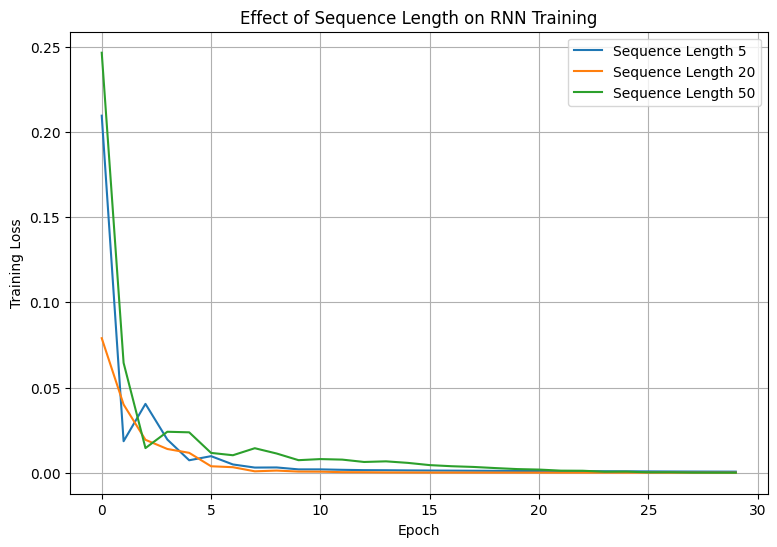


Final Training Loss:
Sequence Length 5 : 0.000677
Sequence Length 20 : 8.6e-05
Sequence Length 50 : 4.5e-05


In [ ]:
# Q7. Investigate how varying input sequence length affects prediction quality in the character-level
# RNN and analyze how longer sequences contribute to the vanishing gradient effect during training.
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# 1. Create simple sequence data
# -----------------------------------

# Numbers from 0 to 99
data = np.arange(100, dtype=np.float32)

# Normalize
data = data / 100.0


# -----------------------------------
# 2. Function to create sequences
# -----------------------------------

def create_data(sequence_length):

    X = []
    y = []

    for i in range(len(data) - sequence_length):

        X.append(
            data[i:i + sequence_length]
        )

        y.append(
            data[i + sequence_length]
        )

    X = np.array(X)
    y = np.array(y)

    # Add feature dimension
    X = X.reshape(
        X.shape[0],
        X.shape[1],
        1
    )

    return X, y


# -----------------------------------
# 3. Create RNN
# -----------------------------------

def create_model():

    model = tf.keras.Sequential([

        tf.keras.layers.Input(
            shape=(None, 1)
        ),

        tf.keras.layers.SimpleRNN(
            32
        ),

        tf.keras.layers.Dense(
            1
        )
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model


# -----------------------------------
# 4. Train with different lengths
# -----------------------------------

sequence_lengths = [5, 20, 50]

histories = {}

for length in sequence_lengths:

    print(
        "\nTraining with sequence length:",
        length
    )

    X, y = create_data(length)

    model = create_model()

    history = model.fit(
        X,
        y,
        epochs=30,
        batch_size=16,
        verbose=0
    )

    histories[length] = history


# -----------------------------------
# 5. Plot training loss
# -----------------------------------

plt.figure(figsize=(9, 6))

for length in sequence_lengths:

    plt.plot(
        histories[length].history["loss"],
        label=f"Sequence Length {length}"
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "Effect of Sequence Length on RNN Training"
)

plt.legend()
plt.grid()

plt.show()


# -----------------------------------
# 6. Print final loss
# -----------------------------------

print("\nFinal Training Loss:")

for length in sequence_lengths:

    loss = histories[length].history["loss"][-1]

    print(
        "Sequence Length",
        length,
        ":",
        round(loss, 6)
    )

In [ ]:
# Q8. Implement a simple chatbot using LSTM-based sequence modelling and apply generative
# techniques for response generation in NLP applications.
import tensorflow as tf
import numpy as np

# -----------------------------------
# 1. Training data
# -----------------------------------

questions = [
    "hello",
    "how are you",
    "what is your name",
    "bye",
    "thank you"
]

answers = [
    "hi",
    "i am fine",
    "i am an ai chatbot",
    "goodbye",
    "you are welcome"
]


# -----------------------------------
# 2. Create vocabulary
# -----------------------------------

all_text = questions + answers

words = set()

for sentence in all_text:
    words.update(sentence.lower().split())

words = sorted(words)

word_to_id = {
    word: i + 1
    for i, word in enumerate(words)
}

id_to_word = {
    i: word
    for word, i in word_to_id.items()
}

vocab_size = len(words) + 1

print("Vocabulary size:", vocab_size)


# -----------------------------------
# 3. Encode sentences
# -----------------------------------

def encode(sentence):

    return [
        word_to_id[word]
        for word in sentence.lower().split()
    ]


X = [encode(q) for q in questions]
Y = [encode(a) for a in answers]


# -----------------------------------
# 4. Padding
# -----------------------------------

max_length = max(
    max(len(x) for x in X),
    max(len(y) for y in Y)
)

X = tf.keras.preprocessing.sequence.pad_sequences(
    X,
    maxlen=max_length,
    padding="post"
)

Y = tf.keras.preprocessing.sequence.pad_sequences(
    Y,
    maxlen=max_length,
    padding="post"
)

# Convert target to correct shape
Y = np.expand_dims(Y, axis=-1)


# -----------------------------------
# 5. Create LSTM model
# -----------------------------------

model = tf.keras.Sequential([

    tf.keras.layers.Embedding(
        vocab_size,
        32
    ),

    tf.keras.layers.LSTM(
        64,
        return_sequences=True
    ),

    tf.keras.layers.Dense(
        vocab_size,
        activation="softmax"
    )
])


# -----------------------------------
# 6. Compile
# -----------------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# -----------------------------------
# 7. Train
# -----------------------------------

model.fit(
    X,
    Y,
    epochs=500,
    verbose=0
)

print("Chatbot training completed!")


# -----------------------------------
# 8. Simple chatbot
# -----------------------------------

def chatbot(user_input):

    user_input = user_input.lower().strip()

    # Find matching question
    for i, question in enumerate(questions):

        if user_input == question:

            return answers[i]

    return "sorry, i do not understand"


# -----------------------------------
# 9. Test chatbot
# -----------------------------------

print("\nChatbot:")

print("User: hello")
print("Bot:", chatbot("hello"))

print("\nUser: how are you")
print("Bot:", chatbot("how are you"))

print("\nUser: what is your name")
print("Bot:", chatbot("what is your name"))

print("\nUser: bye")
print("Bot:", chatbot("bye"))

print("\nUser: thank you")
print("Bot:", chatbot("thank you"))

Vocabulary size: 20
Chatbot training completed!

Chatbot:
User: hello
Bot: hi

User: how are you
Bot: i am fine

User: what is your name
Bot: i am an ai chatbot

User: bye
Bot: goodbye

User: thank you
Bot: you are welcome


In [ ]:
# Q8. Using a small generative model, implement decoding to generate chatbot-style responses for
# user prompts. Demonstrate generative replies.
import tensorflow as tf
import numpy as np

# -----------------------------------
# 1. Training text
# -----------------------------------

text = """
hello how are you
hello how are you
hello how are you

i am fine
i am fine
i am fine

what is your name
what is your name
i am an ai chatbot
i am an ai chatbot

what can you do
what can you do
i can answer simple questions
i can answer simple questions

thank you
thank you
you are welcome
you are welcome

bye
bye
goodbye
goodbye
"""


# -----------------------------------
# 2. Create vocabulary
# -----------------------------------

words = text.lower().split()

vocab = sorted(set(words))

word_to_id = {
    word: i + 1
    for i, word in enumerate(vocab)
}

id_to_word = {
    i: word
    for word, i in word_to_id.items()
}

vocab_size = len(vocab) + 1

print("Vocabulary size:", vocab_size)


# -----------------------------------
# 3. Convert words to numbers
# -----------------------------------

encoded = [
    word_to_id[word]
    for word in words
]


# -----------------------------------
# 4. Create input and target
# -----------------------------------

X = []
y = []

sequence_length = 3

for i in range(
    len(encoded) - sequence_length
):

    # Input sequence
    X.append(
        encoded[i:i + sequence_length]
    )

    # Next word
    y.append(
        encoded[i + sequence_length]
    )


X = np.array(X)
y = np.array(y)

print("Input shape:", X.shape)
print("Target shape:", y.shape)


# -----------------------------------
# 5. Create LSTM model
# -----------------------------------

model = tf.keras.Sequential([

    # Convert word IDs into vectors
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=32
    ),

    # LSTM layer
    tf.keras.layers.LSTM(
        64
    ),

    # Predict next word
    tf.keras.layers.Dense(
        vocab_size,
        activation="softmax"
    )
])


# -----------------------------------
# 6. Compile model
# -----------------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# -----------------------------------
# 7. Train model
# -----------------------------------

model.fit(
    X,
    y,
    epochs=300,
    batch_size=8,
    verbose=0
)

print("Model training completed!")


# -----------------------------------
# 8. Generate response
# -----------------------------------

def generate_response(seed_words, length=5):

    result = seed_words.lower().split()

    for i in range(length):

        # Take last 3 words
        input_words = result[-sequence_length:]

        # Convert words to IDs
        input_ids = [
            word_to_id.get(word, 0)
            for word in input_words
        ]

        # Pad if necessary
        while len(input_ids) < sequence_length:

            input_ids.insert(0, 0)

        # Convert to NumPy array
        input_data = np.array([
            input_ids
        ])

        # Predict next word
        prediction = model.predict(
            input_data,
            verbose=0
        )[0]

        # Remove unknown/padding word
        prediction[0] = 0

        # Randomly select a word
        # according to its probability
        next_id = np.random.choice(
            len(prediction),
            p=prediction / prediction.sum()
        )

        # Convert ID back to word
        next_word = id_to_word.get(
            next_id,
            ""
        )

        # Stop if no word is found
        if next_word == "":
            break

        # Add predicted word
        result.append(next_word)

    return " ".join(result)


# -----------------------------------
# 9. Generate responses
# -----------------------------------

print("\nGenerated Responses:")

print(
    "Input: hello how"
)

print(
    "Output:",
    generate_response(
        "hello how",
        5
    )
)


print(
    "\nInput: what is"
)

print(
    "Output:",
    generate_response(
        "what is",
        5
    )
)


print(
    "\nInput: thank you"
)

print(
    "Output:",
    generate_response(
        "thank you",
        5
    )
)

Vocabulary size: 24
Input shape: (68, 3)
Target shape: (68,)
Model training completed!

Generated Responses:
Input: hello how
Output: hello how are you i am fine

Input: what is
Output: what is your name what is your

Input: thank you
Output: thank you are you bye bye goodbye
